<a href="https://colab.research.google.com/github/lorenalamontes/talento-tech-prediccion-demanda/blob/main/prediccion_demanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Predicción de Demanda de Clientes
## Proyecto TalentoTech — Módulo: Aprendizaje Inteligente
**Equipo:** Carolina Marín · Leidy Lorena Montes · John Camargo · Miguel Hernández · Alexandra Orozco · Andrés Restrepo

In [ ]:
# Instalación de librerías necesarias
!pip install openpyxl -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()  # Selecciona Demanda_Proyecto_IA.xlsx

df = pd.read_excel('Demanda Proyecto IA.xlsx', sheet_name='Cliente ajustado')
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (6656, 16)


,Asesor,Cliente ajustado,Marca,Articulo,6-2025,7-2025,8-2025,9-2025,10-2025,11-2025,12-2025,1-2026,2-2026,3-2026,4-2026,5-2026
0,ADMINISTRACION,Cliente 1,SPS,9994672 96535081 SPS Tijera Delantera Izquierd...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,ADMINISTRACION,Cliente 2,SPS,9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,ADMINISTRACION,Cliente 2,SPS,9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,ADMINISTRACION,Cliente 2,SPS,9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,ADMINISTRACION,Cliente 2,SPS,9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1.0


In [ ]:
# Información general
print("Columnas:", df.columns.tolist())
print("\nValores nulos:\n", df.isnull().sum())
print("\nAsesores únicos:", df['Asesor'].nunique())
print("Clientes únicos:", df['Cliente ajustado'].nunique())
print("Marcas:", df['Marca'].unique())

Columnas: ['Asesor', 'Cliente ajustado', 'Marca', 'Articulo', '6-2025', '7-2025', '8-2025', '9-2025', '10-2025', '11-2025', '12-2025', '1-2026', '2-2026', '3-2026', '4-2026', '5-2026']

Valores nulos:
 Asesor                 0
Cliente ajustado       1
Marca                  1
Articulo               1
6-2025              5661
7-2025              5583
8-2025              5595
9-2025              5699
10-2025             5643
11-2025             5643
12-2025             5594
1-2026              5657
2-2026              5652
3-2026              5533
4-2026              5855
5-2026              5837
dtype: int64

Asesores únicos: 26
Clientes únicos: 754
Marcas: ['SPS' 'Bendix' 'High Brake' 'Knorr' 'Masan-Parts' 'T&J' 'Navcar' 'EMG'
 nan]


In [ ]:
# Las columnas de meses son las últimas 12
meses = ['6-2025','7-2025','8-2025','9-2025','10-2025','11-2025',
         '12-2025','1-2026','2-2026','3-2026','4-2026','5-2026']

# Reemplazar nulos por 0 y negativos por 0 (devoluciones)
df[meses] = df[meses].fillna(0)
df[meses] = df[meses].clip(lower=0)

# Total comprado por fila
df['total_compras'] = df[meses].sum(axis=1)
df['meses_activo'] = (df[meses] > 0).sum(axis=1)
df['promedio_mensual'] = df['total_compras'] / 12

print("Datos limpios:", df.shape)
df[['Asesor','Cliente ajustado','total_compras','meses_activo','promedio_mensual']].head(10)

Datos limpios: (6656, 19)


,Asesor,Cliente ajustado,total_compras,meses_activo,promedio_mensual
0,ADMINISTRACION,Cliente 1,1.0,1,0.083333
1,ADMINISTRACION,Cliente 2,1.0,1,0.083333
2,ADMINISTRACION,Cliente 2,1.0,1,0.083333
3,ADMINISTRACION,Cliente 2,1.0,1,0.083333
4,ADMINISTRACION,Cliente 2,1.0,1,0.083333
5,ADMINISTRACION,Cliente 3,2.0,1,0.166667
6,ADMINISTRACION,Cliente 4,2.0,1,0.166667
7,ADMINISTRACION,Cliente 5,1.0,1,0.083333
8,ADMINISTRACION,Cliente 6,1.0,1,0.083333
9,ADMINISTRACION,Cliente 6,1.0,1,0.083333


In [ ]:
# Agrupación por cliente
clientes = df.groupby('Cliente ajustado').agg(
    total_compras=('total_compras','sum'),
    meses_activo=('meses_activo','sum'),
    num_articulos=('Articulo','count')
).reset_index()

clientes['promedio_mensual'] = clientes['total_compras'] / 12

print("Top 10 clientes por volumen:")
clientes.sort_values('total_compras', ascending=False).head(10)

Top 10 clientes por volumen:


,Cliente ajustado,total_compras,meses_activo,num_articulos,promedio_mensual
99,Cliente 189,1311.0,14,6,109.250000
357,Cliente 420,1171.0,19,21,97.583333
428,Cliente 485,1100.0,103,60,91.666667
573,Cliente 615,1066.0,170,67,88.833333
584,Cliente 625,940.0,23,9,78.333333
191,Cliente 271,870.0,6,3,72.500000
678,Cliente 71,867.0,40,14,72.250000
185,Cliente 266,854.0,30,10,71.166667
81,Cliente 172,751.0,97,42,62.583333
419,Cliente 477,503.0,59,33,41.916667


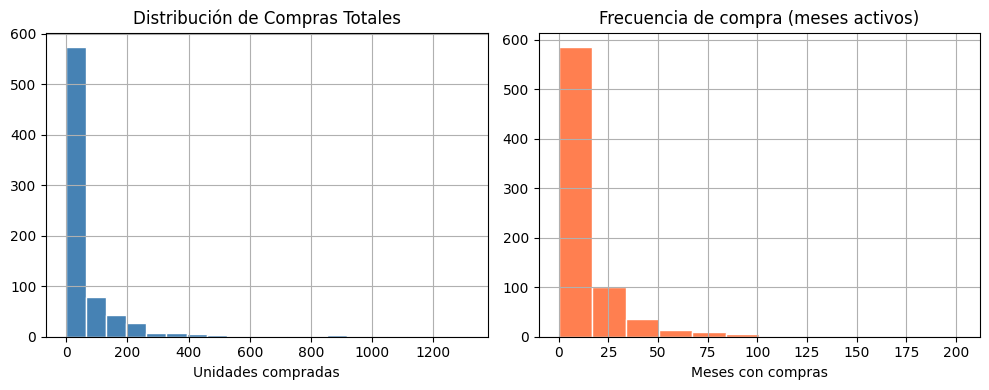

In [ ]:
# Gráfico de distribución de compras
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
clientes['total_compras'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Distribución de Compras Totales')
plt.xlabel('Unidades compradas')

plt.subplot(1,2,2)
clientes['meses_activo'].hist(bins=12, color='coral', edgecolor='white')
plt.title('Frecuencia de compra (meses activos)')
plt.xlabel('Meses con compras')

plt.tight_layout()
plt.show()

                 total_compras  meses_activo
segmento_nombre                             
Alto Potencial      486.333333    129.111111
Bajo Potencial       29.407692      6.592308
Potencial Medio     252.305263     41.494737


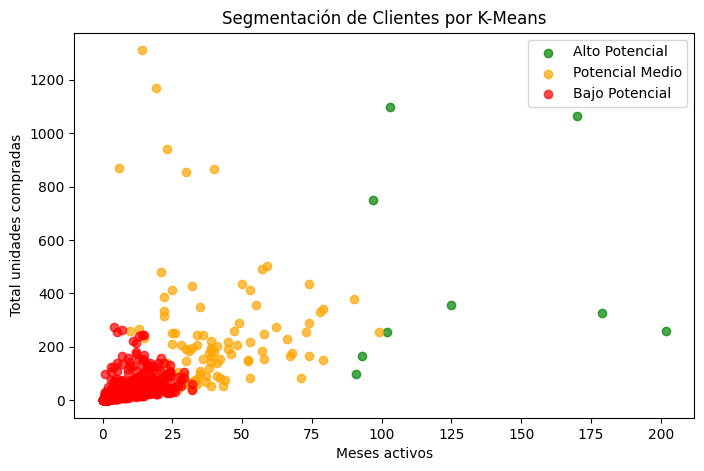

In [ ]:
# Segmentación de clientes
X_cluster = clientes[['total_compras','meses_activo','num_articulos']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clientes['segmento'] = kmeans.fit_predict(X_scaled)

# Renombrar segmentos por volumen
medias = clientes.groupby('segmento')['total_compras'].mean().sort_values()
mapa = {medias.index[0]:'Bajo Potencial', medias.index[1]:'Potencial Medio', medias.index[2]:'Alto Potencial'}
clientes['segmento_nombre'] = clientes['segmento'].map(mapa)

print(clientes.groupby('segmento_nombre')[['total_compras','meses_activo']].mean())

# Visualización
plt.figure(figsize=(8,5))
for seg, color in zip(['Alto Potencial','Potencial Medio','Bajo Potencial'],['green','orange','red']):
    subset = clientes[clientes['segmento_nombre']==seg]
    plt.scatter(subset['meses_activo'], subset['total_compras'], label=seg, alpha=0.7, color=color)
plt.xlabel('Meses activos')
plt.ylabel('Total unidades compradas')
plt.title('Segmentación de Clientes por K-Means')
plt.legend()
plt.show()

MAE: 1.04
R²: 0.025


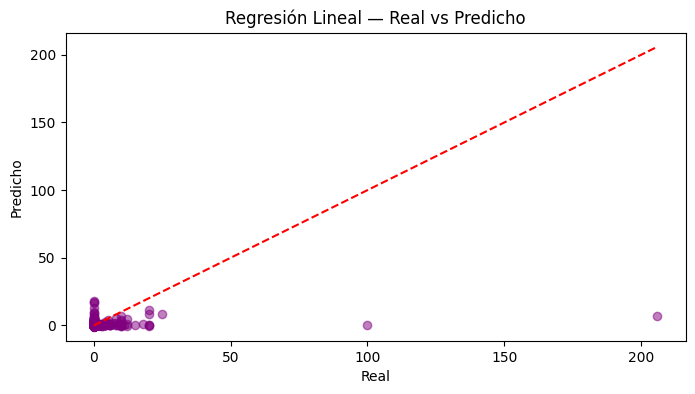

In [ ]:
# Preparar datos para regresión (predecir mes 5-2026 usando los anteriores)
X_reg = df[meses[:-1]].values  # 11 meses como features
y_reg = df[meses[-1]].values   # mes 12 (5-2026) como target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")

# Visualización
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Regresión Lineal — Real vs Predicho')
plt.show()

MAE: 1.04
R²: 0.025


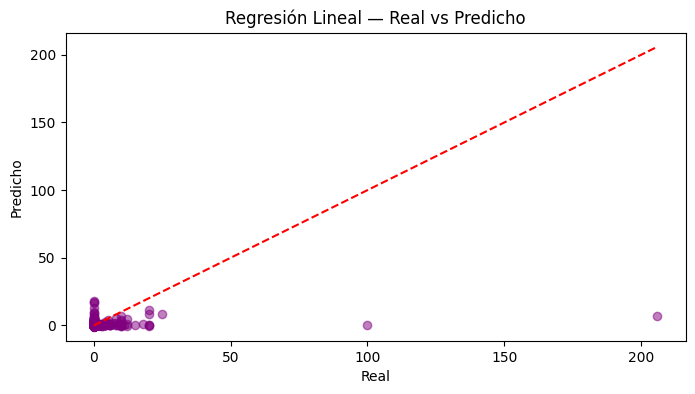

In [ ]:
# Preparar datos para regresión (predecir mes 5-2026 usando los anteriores)
X_reg = df[meses[:-1]].values  # 11 meses como features
y_reg = df[meses[-1]].values   # mes 12 (5-2026) como target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")

# Visualización
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Regresión Lineal — Real vs Predicho')
plt.show()

## 📊 Conclusiones
- El modelo K-Means identificó 3 segmentos de clientes: Alto, Medio y Bajo potencial
- La regresión lineal permite estimar las compras del siguiente mes por artículo
- Los clientes de Alto Potencial deben ser priorizados por los asesores
- Siguiente paso: conectar con CRM y automatizar alertas proactivas
